# Problem Set III - Question 1: Quantum Fourier Transform

**Course:** QPROG - Quantum Programming  
**Students:** Jady Pâmella Barbacena da Silva and Navyashree Suryanarayana Rao Prasanna
**Group:** Group ProblemSet-III-N  
**Assignment:** Implementation of QFT  

This notebook implements the Quantum Fourier Transform (QFT) in Qiskit.

## Environment Setup

Install required packages.

In [1]:
%pip install qiskit==2.2.3
%pip install qiskit-aer==0.17.2
%pip install matplotlib
%pip install numpy
%pip install pylatexenc

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import required libraries
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import numpy as np

## Task 1.2: Implement QFT Rotation Gates

Implement a function that applies the rotation gates needed for QFT on a specific qubit.

In [3]:
def qft_rotations(circuit, n):
    """
    Apply QFT rotation gates on the last qubit of the circuit.
    
    Args:
        circuit: QuantumCircuit to apply rotations to
        n: Number of qubits in the circuit
    """
    if n == 0:
        return circuit
    
    # Apply Hadamard gate to the last qubit
    circuit.h(n-1)
    
    # Apply controlled rotation gates
    for qubit in range(n-1):
        # Apply controlled-R_k gate with angle 2π/2^(n-qubit)
        circuit.cp(np.pi / 2**(n-1-qubit), qubit, n-1)
    
    return circuit

## Task 1.3: Implement SWAP Gates

Implement a function that swaps qubits to reverse their order.

In [4]:
def swap_qubits(circuit, n):
    """
    Swap qubits to reverse their order after QFT.
    
    Args:
        circuit: QuantumCircuit to apply swaps to
        n: Number of qubits in the circuit
    """
    for qubit in range(n // 2):
        circuit.swap(qubit, n - qubit - 1)
    
    return circuit

## Task 1.4: Complete QFT Implementation

Implement the complete Quantum Fourier Transform by combining rotations and swaps.

In [5]:
def qft(circuit, n):
    """
    Apply complete QFT on the first n qubits of the circuit.
    
    Args:
        circuit: QuantumCircuit to apply QFT to
        n: Number of qubits to apply QFT on
    """
    # Apply QFT rotations on each qubit recursively
    for i in range(n):
        qft_rotations(circuit, n - i)
    
    # Swap qubits to reverse the order
    swap_qubits(circuit, n)
    
    return circuit

## Test and Visualization

Test the QFT implementation with different numbers of qubits.

QFT Circuit:
                                          ┌───┐   
q_0: ──────■──────────────────────■───────┤ H ├─X─
           │                ┌───┐ │P(π/2) └───┘ │ 
q_1: ──────┼────────■───────┤ H ├─■─────────────┼─
     ┌───┐ │P(π/4)  │P(π/2) └───┘               │ 
q_2: ┤ H ├─■────────■───────────────────────────X─
     └───┘                                        


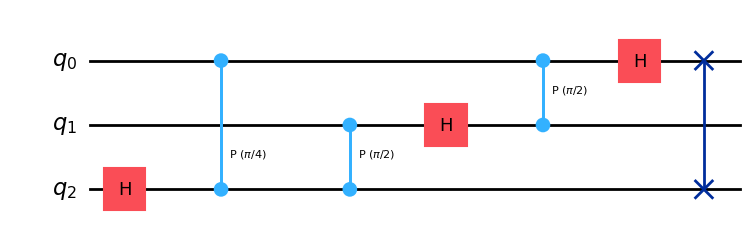

In [6]:
# Test QFT with 3 qubits
n = 3
circuit = QuantumCircuit(n)

# Apply QFT
qft(circuit, n)

print("QFT Circuit:")
print(circuit)
circuit.draw('mpl')

In [7]:
# Test with different input state
n = 4
circuit = QuantumCircuit(n)

# Prepare initial state |0001⟩
circuit.x(0)

# Apply QFT
qft(circuit, n)

# Add measurements
circuit.measure_all()

print("QFT with initial state |0001⟩:")
print(circuit)

QFT with initial state |0001⟩:
        ┌───┐                                                                »
   q_0: ┤ X ├─■───────────────────────────────■──────────────────────■───────»
        └───┘ │                               │                ┌───┐ │P(π/2) »
   q_1: ──────┼────────■──────────────────────┼────────■───────┤ H ├─■───────»
              │        │                ┌───┐ │P(π/4)  │P(π/2) └───┘         »
   q_2: ──────┼────────┼────────■───────┤ H ├─■────────■─────────────────────»
        ┌───┐ │P(π/8)  │P(π/4)  │P(π/2) └───┘                                »
   q_3: ┤ H ├─■────────■────────■────────────────────────────────────────────»
        └───┘                                                                »
meas: 4/═════════════════════════════════════════════════════════════════════»
                                                                             »
«        ┌───┐    ░ ┌─┐         
«   q_0: ┤ H ├─X──░─┤M├─────────
«        └───┘ │  ░ └╥┘┌─┐      
«